# Subgraphs

This guide explains the mechanics of using subgraphs. A subgraph is a graph that is used as a `node` in another `graph`.

Subgraphs are useful for:

* Building *multi-agent systems*
* Reusing a set of nodes in *multiple graphs*
* Distributing development: when you want different teams to work on different parts of the graph independently, you can define each part as a subgraph, and as long as the subgraph interface (the input and output schemas) is respected, the parent graph can be built without knowing any details of the subgraph

In [28]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

## Define subgraph communication

When adding subgraphs, you need to define how the **parent graph** and the **subgraph** communicate:

| Pattern | When to use | State Schemas |
| --- | --- | --- |
| Call a subgraph inside a node | Parent and subgraph have **different state schemas** (no shared keys), or you need to transform state between them | You write a wrapper function that maps parent state to subgraph input and subgraph output back to parent state |
| Add a subgraph as a node | Parent and subgraph **share state keys** —the subgraph reads from and writes to the same channels as the parent | You pass the compiled subgraph directly to add_node—no wrapper function needed |

## Call a subgraph inside a node

When the parent graph and subgraph have **different state schemas** (no shared keys), invoke the subgraph inside a node function. This is common when you want to keep a private message history for each agent in a multi-agent system.

The node function transforms the parent state to the subgraph state before invoking the subgraph, and transforms the results back to the parent state before returning.

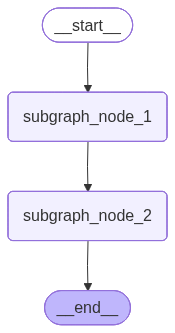

() {'node_1': {'foo': 'hi! foo'}}
('node_2:1aaf8327-d403-5a03-059d-1730eb005447',) {'subgraph_node_1': {'baz': 'baz'}}
('node_2:1aaf8327-d403-5a03-059d-1730eb005447',) {'subgraph_node_2': {'bar': 'hi! foobaz'}}
() {'node_2': {'foo': 'hi! foobaz'}}


In [27]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image


# Define subgraph
class SubgraphState(TypedDict):
    # note that none of these keys are shared with the parent graph state
    bar: str
    baz: str


def subgraph_node_1(state: SubgraphState):
    return {"baz": "baz"}


def subgraph_node_2(state: SubgraphState):
    return {"bar": state["bar"] + state["baz"]}


subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_node(subgraph_node_2)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph_builder.add_edge("subgraph_node_1", "subgraph_node_2")
subgraph = subgraph_builder.compile()
display(Image(subgraph.get_graph().draw_mermaid_png()))


# Define parent graph
class ParentState(TypedDict):
    foo: str


def node_1(state: ParentState):
    return {"foo": "hi! " + state["foo"]}


def node_2(state: ParentState):
    # Transform the state to the subgraph state
    response = subgraph.invoke({"bar": state["foo"]})
    # Transform response back to the parent state
    return {"foo": response["bar"]}


builder = StateGraph(ParentState)
builder.add_node(node_1)
builder.add_node(node_2)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

graph = builder.compile()


for chunk in graph.stream({"foo": "foo"}, subgraphs=True, version="v2"):
    if chunk["type"] == "updates":
        print(chunk["ns"], chunk["data"])

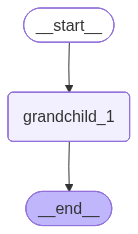

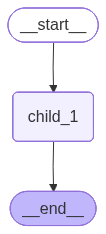

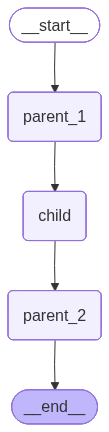

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image


class GrandChildState(TypedDict):
    my_grandchild_key: str


def grandchild_1(state: GrandChildState) -> GrandChildState:
    # NOTE: child or parent keys will not be accessible here
    return {"my_grandchild_key": state["my_grandchild_key"] + ", how are you"}


grandchild = StateGraph(GrandChildState)
grandchild.add_node("grandchild_1", grandchild_1)

grandchild.add_edge(START, "grandchild_1")
grandchild.add_edge("grandchild_1", END)

grandchild_graph = grandchild.compile()
display(Image(grandchild_graph.get_graph().draw_mermaid_png()))


# Child graph
class ChildState(TypedDict):
    my_child_key: str


def call_grandchild_graph(state: ChildState) -> ChildState:
    # NOTE: parent or grandchild keys won't be accessible here
    grandchild_graph_input = {"my_grandchild_key": state["my_child_key"]}
    grandchild_graph_output = grandchild_graph.invoke(grandchild_graph_input)
    return {"my_child_key": grandchild_graph_output["my_grandchild_key"] + " today?"}


child = StateGraph(ChildState)
# We're passing a function here instead of just compiled graph (`grandchild_graph`)
child.add_node("child_1", call_grandchild_graph)
child.add_edge(START, "child_1")
child.add_edge("child_1", END)
child_graph = child.compile()
display(Image(child_graph.get_graph().draw_mermaid_png()))


# Parent graph
class ParentState(TypedDict):
    my_key: str


def parent_1(state: ParentState) -> ParentState:
    # NOTE: child or grandchild keys won't be accessible here
    return {"my_key": "hi " + state["my_key"]}


def parent_2(state: ParentState) -> ParentState:
    return {"my_key": state["my_key"] + " bye!"}


def call_child_graph(state: ParentState) -> ParentState:
    child_graph_input = {"my_child_key": state["my_key"]}
    child_graph_output = child_graph.invoke(child_graph_input)
    return {"my_key": child_graph_output["my_child_key"]}


parent = StateGraph(ParentState)
parent.add_node("parent_1", parent_1)
# We're passing a function here instead of just a compiled graph (`child_graph`)
parent.add_node("child", call_child_graph)
parent.add_node("parent_2", parent_2)

parent.add_edge(START, "parent_1")
parent.add_edge("parent_1", "child")
parent.add_edge("child", "parent_2")
parent.add_edge("parent_2", END)

parent_graph = parent.compile()
display(Image(parent_graph.get_graph().draw_mermaid_png()))

In [12]:
for chunk in parent_graph.stream({"my_key": "Bob"}, subgraphs=True, version="v2"):
    if chunk["type"] == "updates":
        print(chunk["ns"], chunk["data"])

() {'parent_1': {'my_key': 'hi Bob'}}
('child:cffa90a0-310a-87e5-6753-a2c943854252', 'child_1:88f3416c-3be9-073d-d554-9ce0597373ca') {'grandchild_1': {'my_grandchild_key': 'hi Bob, how are you'}}
('child:cffa90a0-310a-87e5-6753-a2c943854252',) {'child_1': {'my_child_key': 'hi Bob, how are you today?'}}
() {'child': {'my_key': 'hi Bob, how are you today?'}}
() {'parent_2': {'my_key': 'hi Bob, how are you today? bye!'}}


## Add a subgraph as a node

When the parent graph and subgraph share state keys, you can pass a compiled subgraph directly to `add_node`. No wrapper function is needed—the subgraph reads from and writes to the parent’s state channels automatically. For example, in multi-agent systems, the agents often communicate over a shared messages key.

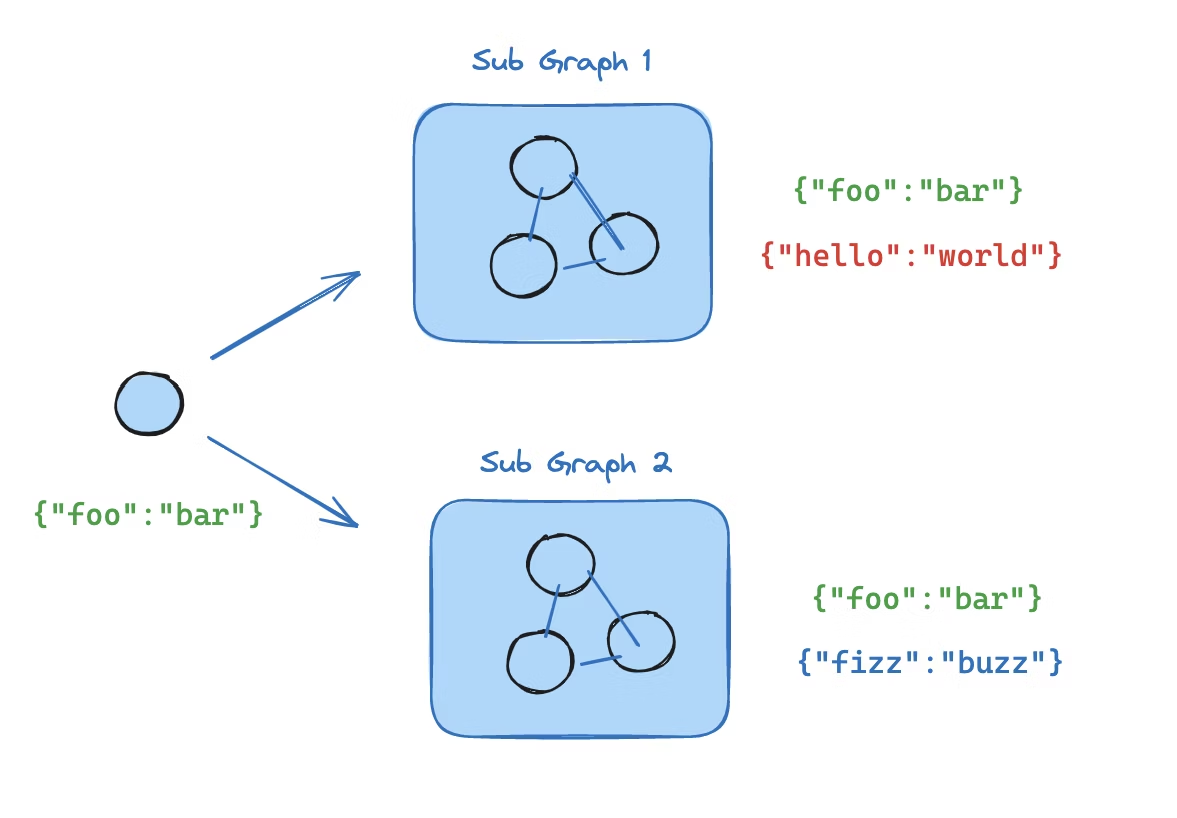

If your subgraph shares state keys with the parent graph, you can follow these steps to add it to your graph:

1. Define the subgraph workflow (subgraph_builder in the example below) and compile it
2. Pass compiled subgraph to the add_node method when defining the parent graph workflow

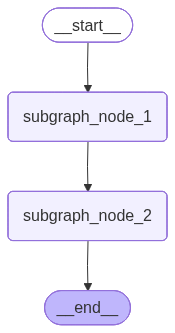

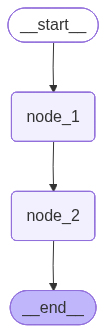

{'node_1': {'foo': 'hi! foo'}}
{'node_2': {'foo': 'hi! foobar'}}


In [ ]:
from typing_extensions import TypedDict
from langgraph.graph.state import StateGraph, START
from IPython.display import display, Image


# Define subgraph
class SubgraphState(TypedDict):
    foo: str  # shared with parent graph state
    bar: str  # private to SubgraphState


def subgraph_node_1(state: SubgraphState):
    return {"bar": "bar"}


def subgraph_node_2(state: SubgraphState):
    # note that this node is using a state key ('bar') that is only available in the subgraph
    # and is sending update on the shared state key ('foo')
    return {"foo": state["foo"] + state["bar"]}


subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_node(subgraph_node_2)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph_builder.add_edge("subgraph_node_1", "subgraph_node_2")
subgraph = subgraph_builder.compile()
display(Image(subgraph.get_graph().draw_mermaid_png()))


# Define parent graph
class ParentState(TypedDict):
    foo: str


def node_1(state: ParentState):
    return {"foo": "hi! " + state["foo"]}


builder = StateGraph(ParentState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", subgraph)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

for chunk in graph.stream({"foo": "foo"}, version="v2"):
    if chunk["type"] == "updates":
        print(chunk["data"])

## Subgraph persistence

When you use a subgraph, you need to decide what happens to its internal data between calls. Consider a customer support bot that delegates to specialist subagents: should the “billing expert” subagent remember the customer’s earlier questions, or start fresh each time it’s called?

The `checkpointer` parameter on .`compile`() controls subgraph persistence:

| Mode | `checkpointers`= | Behavior |
| ---- | ---------------- | -------- |
| Per-invocation | `None` (Default) | Each call starts fresh and inherits the parent’s checkpointer to support interrupts and durable execution within a single call.|
| Per-thread | `True` | State accumulates across calls on the same thread. Each call picks up where the last one left off.|
| Stateless | `False` | No checkpointing at all—runs like a plain function call. No interrupts or durable execution.|

Per-invocation is the right choice for most applications, including multi-agent systems where subagents handle independent requests. Use per-thread when a subagent needs multi-turn conversation memory (for example, a research assistant that builds context over several exchanges).

## Stateful

Stateful subgraphs inherit the parent graph’s checkpointer, which enables interrupts, durable execution, and state inspection. The two stateful modes differ in how long state is retained.

### Per-invocation (default)

This is the recommended mode for most applications, including multi-agent systems where subagents are invoked as tools. It supports interrupts, durable execution, and parallel calls while keeping each invocation isolated.

Use per-invocation persistence when each call to the subgraph is independent and the subagent doesn’t need to remember anything from previous calls. This is the most common pattern, especially for multi-agent systems where subagents handle one-off requests like “look up this customer’s order” or “summarize this document.”

Omit `checkpointer` or set it to `None`. Each call starts fresh, but within a single call the subgraph inherits the parent’s checkpointer and can use `interrupt`() to pause and resume.

The following examples use two subagents (fruit expert, veggie expert) wrapped as tools for an outer agent:

In [37]:
from langchain.agents import create_agent
from langchain.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt


@tool
def fruit_info(fruit_name: str) -> str:
    """Look up fruit info."""
    interrupt("continue?")
    return f"Info about {fruit_name}"


@tool
def veggie_info(veggie_name: str) -> str:
    """Look up veggie info."""
    return f"Info about {veggie_name}"


# Subagents - no checkpointer setting (inherits parent)
fruit_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[fruit_info],
    system_prompt="You are a fruit expert. Use the fruit_info tool. Respond in one sentence.",
)

veggie_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[veggie_info],
    system_prompt="You are a veggie expert. Use the veggie_info tool. Respond in one sentence.",
)


# Wrap subagents as tools for the outer agent
@tool
def ask_fruit_expert(question: str) -> str:
    """Ask the fruit expert. Use for ALL fruit questions."""
    response = fruit_agent.invoke(
        {"messages": [{"role": "user", "content": question}]},
    )
    return response["messages"][-1].content


@tool
def ask_veggie_expert(question: str) -> str:
    """Ask the veggie expert. Use for ALL veggie questions."""
    response = veggie_agent.invoke(
        {"messages": [{"role": "user", "content": question}]},
    )
    return response["messages"][-1].content


# Outer agent with checkpointer
agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[ask_fruit_expert, ask_veggie_expert],
    system_prompt=(
        "You have two experts: ask_fruit_expert and ask_veggie_expert. "
        "ALWAYS delegate questions to the appropriate expert."
    ),
    checkpointer=MemorySaver(),
)

# Each invocation can use interrupt() to pause and resume. Add interrupt() to a tool function
# to require user approval before proceeding:


config = {"configurable": {"thread_id": "1"}}

# Invoke - the subagent's tool calls interrupt()
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Tell me about apples"}]},
    config=config,
)
# response contains __interrupt__

# Resume - approve the interrupt
response = agent.invoke(Command(resume=True), config=config)
# Subagent message count: 4
print(response["messages"][-1].content)
print("Subagent message count:", len(response["messages"]))

Apples are a popular fruit known for their crisp texture and sweet to tart flavor, making them versatile for eating fresh, baking, or cooking.
Subagent message count: 4


In [40]:
from langchain.agents import create_agent
from langchain.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt


@tool
def fruit_info(fruit_name: str) -> str:
    """Look up fruit info."""
    # interrupt("continue?")
    return f"Info about {fruit_name}"


@tool
def veggie_info(veggie_name: str) -> str:
    """Look up veggie info."""
    return f"Info about {veggie_name}"


# Subagents - no checkpointer setting (inherits parent)
fruit_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[fruit_info],
    system_prompt="You are a fruit expert. Use the fruit_info tool. Respond in one sentence.",
)

veggie_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[veggie_info],
    system_prompt="You are a veggie expert. Use the veggie_info tool. Respond in one sentence.",
)


# Wrap subagents as tools for the outer agent
@tool
def ask_fruit_expert(question: str) -> str:
    """Ask the fruit expert. Use for ALL fruit questions."""
    response = fruit_agent.invoke(
        {"messages": [{"role": "user", "content": question}]},
    )
    return response["messages"][-1].content


@tool
def ask_veggie_expert(question: str) -> str:
    """Ask the veggie expert. Use for ALL veggie questions."""
    response = veggie_agent.invoke(
        {"messages": [{"role": "user", "content": question}]},
    )
    return response["messages"][-1].content


# Outer agent with checkpointer
agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[ask_fruit_expert, ask_veggie_expert],
    system_prompt=(
        "You have two experts: ask_fruit_expert and ask_veggie_expert. "
        "ALWAYS delegate questions to the appropriate expert."
    ),
    checkpointer=MemorySaver(),
)

# Each invocation starts with a fresh subagent state. The subagent does not remember previous calls:

config = {"configurable": {"thread_id": "1"}}

# First call
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Tell me about apples"}]},
    config=config,
)
# Subagent message count: 4

# Second call - subagent starts fresh, no memory of apples
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Now tell me about bananas"}]},
    config=config,
)
# Subagent message count: 4 (still fresh!)
print(response["messages"][-1].content)
print("Subagent message count:", len(response["messages"]))

Bananas are tropical fruits known for their sweet taste and creamy texture. They have a high potassium content, which makes them a popular choice for snacking and healthy diets.
Subagent message count: 8


In [41]:
config = {"configurable": {"thread_id": "1"}}

# LLM calls ask_fruit_expert for both apples and bananas
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Tell me about apples and bananas"}]},
    config=config,
)
# Subagent message count: 4 (apples - fresh)
# Subagent message count: 4 (bananas - fresh)
print(response["messages"][-1].content)
print("Subagent message count:", len(response["messages"]))

Apples are a popular fruit known for their crisp texture and sweet to tart flavor, and they are rich in vitamins, fiber, and antioxidants. 

Bananas, on the other hand, are elongated, tropical fruits characterized by their yellow peel and soft flesh. They are high in potassium, making them a popular choice for snacks and smoothies.
Subagent message count: 13


### Per-thread

Use per-thread persistence when a subagent needs to remember previous interactions. For example, a research assistant that builds up context over several exchanges, or a coding assistant that tracks what files it has already edited. The subagent’s conversation history and data accumulate across calls on the same thread. Each call picks up where the last one left off.

Compile with `checkpointer=True` to enable this behavior.

In [48]:
from langchain.agents import create_agent
from langchain.agents.middleware import ToolCallLimitMiddleware
from langchain.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt


@tool
def fruit_info(fruit_name: str) -> str:
    """Look up fruit info."""
    return f"Info about {fruit_name}"


# Subagent with checkpointer=True for persistent state
fruit_agent = create_agent(
    model="gpt-4.1-mini",
    tools=[fruit_info],
    system_prompt="You are a fruit expert. Use the fruit_info tool. Respond in one sentence.",
    checkpointer=True,
)


# Wrap subagent as a tool for the outer agent
@tool
def ask_fruit_expert(question: str) -> str:
    """Ask the fruit expert. Use for ALL fruit questions."""
    response = fruit_agent.invoke(
        {"messages": [{"role": "user", "content": question}]},
    )
    return response["messages"][-1].content


# Outer agent with checkpointer
# Use ToolCallLimitMiddleware to prevent parallel calls to per-thread subagents,
# which would cause checkpoint conflicts.
agent = create_agent(
    model="gpt-4.1-mini",
    tools=[ask_fruit_expert],
    system_prompt="You have a fruit expert. ALWAYS delegate fruit questions to ask_fruit_expert.",
    middleware=[
        ToolCallLimitMiddleware(tool_name="ask_fruit_expert", run_limit=1),
    ],
    checkpointer=MemorySaver(),
)

In [ ]:
# Per-thread subagents support interrupt() just like per-invocation. Add interrupt()
# to a tool function to require user approval:


@tool
def fruit_info(fruit_name: str) -> str:
    """Look up fruit info."""
    interrupt("continue?")
    return f"Info about {fruit_name}"


config = {"configurable": {"thread_id": "1"}}

# Invoke - the subagent's tool calls interrupt()
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Tell me about apples"}]},
    config=config,
)
# response contains __interrupt__

# Resume - approve the interrupt
response = agent.invoke(Command(resume=True), config=config)
# Subagent message count: 4
print(response["messages"][-1].content)
print("Subagent message count:", len(response["messages"]))

Apples are a popular fruit known for their sweet to tart flavor and crisp texture. They are versatile and can be eaten fresh, cooked, or baked in various dishes. If you want, I can provide more detailed information about apple varieties, nutritional benefits, or uses.
Subagent message count: 4


In [53]:
from langchain.agents import create_agent
from langchain.agents.middleware import ToolCallLimitMiddleware
from langchain.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt


@tool
def fruit_info(fruit_name: str) -> str:
    """Look up fruit info."""
    return f"Info about {fruit_name}"


# Subagent with checkpointer=True for persistent state
fruit_agent = create_agent(
    model="gpt-4.1-mini",
    tools=[fruit_info],
    system_prompt="You are a fruit expert. Use the fruit_info tool. Respond in one sentence.",
    checkpointer=True,
)


# Wrap subagent as a tool for the outer agent
@tool
def ask_fruit_expert(question: str) -> str:
    """Ask the fruit expert. Use for ALL fruit questions."""
    response = fruit_agent.invoke(
        {"messages": [{"role": "user", "content": question}]},
    )
    return response["messages"][-1].content


# Outer agent with checkpointer
# Use ToolCallLimitMiddleware to prevent parallel calls to per-thread subagents,
# which would cause checkpoint conflicts.
agent = create_agent(
    model="gpt-4.1-mini",
    tools=[ask_fruit_expert],
    system_prompt="You have a fruit expert. ALWAYS delegate fruit questions to ask_fruit_expert.",
    middleware=[
        ToolCallLimitMiddleware(tool_name="ask_fruit_expert", run_limit=1),
    ],
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": "1"}}

# First call
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Tell me about apples"}]},
    config=config,
)
# Subagent message count: 4

# Second call - subagent REMEMBERS apples conversation
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Now tell me about bananas"}]},
    config=config,
)
# Subagent message count: 8 (accumulated!)

print(response["messages"][-1].content)
print("Subagent message count:", len(response["messages"]))

Bananas are a tropical fruit known for their creamy texture and sweet taste. They are rich in potassium, vitamin B6, vitamin C, and dietary fiber, making them a nutritious and energy-boosting snack. If you want more information about bananas, just let me know!
Subagent message count: 8


In [57]:
from langgraph.graph import MessagesState, StateGraph


def create_sub_agent(model, *, name, **kwargs):
    """Wrap an agent with a unique node name for namespace isolation."""
    agent = create_agent(model=model, name=name, **kwargs)
    return (
        StateGraph(MessagesState)
        .add_node(name, agent)  # unique name → stable namespace  #
        .add_edge("__start__", name)
        .compile()
    )


fruit_agent = create_sub_agent(
    "gpt-4.1-mini",
    name="fruit_agent",
    tools=[fruit_info],
    system_prompt="You have a fruit expert. ALWAYS delegate fruit questions to ask_fruit_expert.",
    checkpointer=True,
)
veggie_agent = create_sub_agent(
    "gpt-4.1-mini",
    name="veggie_agent",
    system_prompt="You have a vegetable expert. ALWAYS delegate vegetable questions to ask_fruit_expert.",
    tools=[veggie_info],
    checkpointer=True,
)

config = {"configurable": {"thread_id": "1"}}

# First call - LLM calls both fruit and veggie experts
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Tell me about cherries and broccoli"}]},
    config=config,
)
# Fruit subagent message count: 4
# Veggie subagent message count: 4

# Second call - both agents accumulate independently
response = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "Now tell me about oranges and carrots"}
        ]
    },
    config=config,
)
# Fruit subagent message count: 8 (remembers cherries!)
# Veggie subagent message count: 8 (remembers broccoli!)

print(response["messages"][-1].content)
print("Subagent message count:", len(response["messages"]))

Oranges are a popular citrus fruit known for their bright orange color and juicy, sweet-tart flavor. They are rich in vitamin C, fiber, and antioxidants, making them a healthy snack choice. Oranges can be eaten fresh, juiced, or used in cooking and baking. There are various varieties including navel, blood, and Valencia oranges.

Regarding carrots, I have reached my limit on fruit expert inquiries and cannot provide expert details at this moment. However, carrots are root vegetables known for their orange color (though they come in other colors as well) and are rich in beta-carotene, fiber, vitamin K1, and antioxidants.

If you'd like, I can share more about oranges or general info about carrots!
Subagent message count: 18


## Stateless

Use this when you want to run a subagent like a plain function call with no checkpointing overhead. The subgraph cannot pause/resume and does not benefit from durable execution. Compile with `checkpointer=False`.

Without checkpointing, the subgraph has no durable execution. If the process crashes mid-run, the subgraph cannot recover and must be re-run from the beginning.

In [58]:
from langchain.agents import create_agent
from langchain.agents.middleware import ToolCallLimitMiddleware
from langchain.tools import tool
from langgraph.types import Command, interrupt


@tool
def fruit_info(fruit_name: str) -> str:
    """Look up fruit info."""
    return f"Info about {fruit_name}"


# Subagent with checkpointer=True for persistent state
fruit_agent = create_agent(
    model="gpt-4.1-mini",
    tools=[fruit_info],
    system_prompt="You are a fruit expert. Use the fruit_info tool. Respond in one sentence.",
    checkpointer=True,
)


# Wrap subagent as a tool for the outer agent
@tool
def ask_fruit_expert(question: str) -> str:
    """Ask the fruit expert. Use for ALL fruit questions."""
    response = fruit_agent.invoke(
        {"messages": [{"role": "user", "content": question}]},
    )
    return response["messages"][-1].content


# Outer agent with checkpointer
# Use ToolCallLimitMiddleware to prevent parallel calls to per-thread subagents,
# which would cause checkpoint conflicts.
agent = create_agent(
    model="gpt-4.1-mini",
    tools=[ask_fruit_expert],
    system_prompt="You have a fruit expert. ALWAYS delegate fruit questions to ask_fruit_expert.",
    middleware=[
        ToolCallLimitMiddleware(tool_name="ask_fruit_expert", run_limit=1),
    ],
    checkpointer=False,
)

In [61]:
config = {"configurable": {"thread_id": "1"}}

# First call
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Tell me about apples"}]},
    config=config,
)
# Subagent message count: 4

# Second call - subagent REMEMBERS apples conversation
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Now tell me about bananas"}]},
    config=config,
)
# Subagent message count: 8 (accumulated!)
print(response["messages"][-1].content)
print("Subagent message count:", len(response["messages"]))

Bananas are a popular tropical fruit known for their creamy texture, sweet taste, and high potassium content. If you'd like to know more details about bananas, feel free to ask!
Subagent message count: 4


| Feature |	Per-invocation (default)	| Per-thread	| Stateless |
| ------- | --------------------------- | ------------  | --------- | 
|`checkpointer=`	|`None`	|`True`	|`False` |
|Interrupts (HITL)	|✅	|✅	|❌|
|Multi-turn memory	|❌	|✅	|❌|
|Multiple calls (different subgraphs)	|✅	|⚠️	|✅|
|Multiple calls (same subgraph)	|✅	|❌	|✅|
|State inspection	|⚠️	|✅	|❌|

## View subgraph state

When you enable persistence, you can inspect the subgraph state using the subgraphs option. With stateless checkpointing (checkpointer=False), no subgraph checkpoints are saved, so subgraph state is not available.

Viewing subgraph state requires that LangGraph can statically discover the subgraph—i.e., it is added as a node or called inside a node. It does not work when a subgraph is called inside a tool function or other indirection (e.g., the subagents pattern). Interrupts still propagate to the top-level graph regardless of nesting.

In [ ]:
# Pre-invocation
# Returns subgraph state for the current invocation only. Each invocation starts fresh.

from langgraph.graph import START, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from typing_extensions import TypedDict


class State(TypedDict):
    foo: str


# Subgraph
def subgraph_node_1(state: State):
    value = interrupt("Provide value:")
    return {"foo": state["foo"] + value}


subgraph_builder = StateGraph(State)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph = subgraph_builder.compile()  # inherits parent checkpointer

# Parent graph
builder = StateGraph(State)
builder.add_node("node_1", subgraph)
builder.add_edge(START, "node_1")

checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "1"}}

graph.invoke({"foo": ""}, config)

# View subgraph state for the current invocation
subgraph_state = graph.get_state(config, subgraphs=True).tasks[0].state

# Resume the subgraph
graph.invoke(Command(resume="bar"), config)

{'foo': 'bar'}

In [65]:
# Per-thread
# Returns accumulated subgraph state across all invocations on this thread.

from langgraph.graph import START, StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver

# Subgraph with its own persistent state
subgraph_builder = StateGraph(MessagesState)
# ... add nodes and edges
subgraph_builder = StateGraph(State)
subgraph_builder.add_node("node_1", subgraph)
subgraph_builder.add_edge(START, "node_1")

subgraph = subgraph_builder.compile(checkpointer=True)

# Parent graph
builder = StateGraph(MessagesState)
builder.add_node("agent", subgraph)
builder.add_edge(START, "agent")

checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "1"}}

graph.invoke({"messages": [{"role": "user", "content": "hi"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "what did I say?"}]}, config)

# View accumulated subgraph state (includes messages from both invocations)
subgraph_state = graph.get_state(config, subgraphs=True).tasks[0].state

## Stream subgraph outputs

To include outputs from subgraphs in the streamed outputs, you can set the subgraphs option in the stream method of the parent graph. This will stream outputs from both the parent graph and any subgraphs.

In [66]:
from typing_extensions import TypedDict
from langgraph.graph.state import StateGraph, START


# Define subgraph
class SubgraphState(TypedDict):
    foo: str
    bar: str


def subgraph_node_1(state: SubgraphState):
    return {"bar": "bar"}


def subgraph_node_2(state: SubgraphState):
    # note that this node is using a state key ('bar') that is only available in the subgraph
    # and is sending update on the shared state key ('foo')
    return {"foo": state["foo"] + state["bar"]}


subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_node(subgraph_node_2)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph_builder.add_edge("subgraph_node_1", "subgraph_node_2")
subgraph = subgraph_builder.compile()


# Define parent graph
class ParentState(TypedDict):
    foo: str


def node_1(state: ParentState):
    return {"foo": "hi! " + state["foo"]}


builder = StateGraph(ParentState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", subgraph)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
graph = builder.compile()

for chunk in graph.stream(
    {"foo": "foo"},
    stream_mode="updates",
    subgraphs=True,
    version="v2",
):
    if chunk["type"] == "updates":
        print(chunk["ns"], chunk["data"])

() {'node_1': {'foo': 'hi! foo'}}
('node_2:671007c1-331f-442e-c5cf-d31b7e82a7d5',) {'subgraph_node_1': {'bar': 'bar'}}
('node_2:671007c1-331f-442e-c5cf-d31b7e82a7d5',) {'subgraph_node_2': {'foo': 'hi! foobar'}}
() {'node_2': {'foo': 'hi! foobar'}}
